# Mechanistic Test of Oversquashing and Attention Dilution on Real Data

This notebook directly tests the two failure modes from your thesis on the **Peptides-func** dataset (LRGB). Unlike the previous notebooks, it does not infer mechanism from accuracy gaps — it measures the mechanistic quantities themselves on trained models running on real graphs.

Four measurements, each grounded in published theory:

1. **Effective resistance per graph** (Di Giovanni et al. ICML 2023): the structural quantity that bounds Jacobian-based oversquashing. Computed exactly from each graph's Laplacian pseudo-inverse.
2. **Stratified evaluation**: split the test set into low/medium/high effective-resistance bins; report per-bin Average Precision per model. If oversquashing matters, the local→global gap should widen with bin index.
3. **Jacobian sensitivity** $\|\partial h_v / \partial x_u\|_F$ between node pairs $(u,v)$ as a function of their effective resistance. Per Di Giovanni et al., MPNN Jacobians should decay roughly as $1/R_\text{eff}$; transformer Jacobians should not.
4. **Attention entropy** per graph as a function of graph size. If dilution matters, entropy should rise with size.

**Models** (three, chosen to span local/global/hybrid):
- **GINE** — local MPNN with edge features. Strongest local baseline on Peptides.
- **GraphTransformer** — pure global attention. Pure dilution-prone, oversquashing-immune.
- **GPS** — hybrid: GINE branch + global attention per layer.

All three share an identical skeleton; only the inner layer changes. Each exposes a `node_embeddings()` method (returns node-level representations before pooling) so the Jacobian can be computed at the right scale, and attention models cache attention weights so entropy can be logged.

## 0. Install

In [1]:
!pip install torch torch_geometric matplotlib scikit-learn networkx scipy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.8 MB/s eta 0:00:00


## 1. Setup

In [2]:
import random, time
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import average_precision_score
from scipy.stats import pearsonr, linregress

from torch_geometric.loader import DataLoader
from torch_geometric.datasets import LRGBDataset
from torch_geometric.nn import GINConv, GINEConv, global_add_pool
from torch_geometric.utils import to_dense_batch, to_networkx

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CONFIG = {
    "HIDDEN": 96,
    "LAYERS": 5,
    "EPOCHS": 30,           # bump for serious numbers
    "BATCH": 128,
    "LR": 1e-3,
    "HEADS": 4,
    "DROPOUT": 0.1,
    "N_GRAPHS_JACOBIAN": 30,    # graphs sampled for Jacobian measurement
    "N_PAIRS_PER_GRAPH": 8,     # node pairs per graph
    "N_ER_BINS": 3,             # stratification bins
}
for k, v in CONFIG.items(): print(f"  {k}: {v}")

def set_seed(s):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)

set_seed(0)

Device: cuda
  HIDDEN: 96
  LAYERS: 5
  EPOCHS: 30
  BATCH: 128
  LR: 0.001
  HEADS: 4
  DROPOUT: 0.1
  N_GRAPHS_JACOBIAN: 30
  N_PAIRS_PER_GRAPH: 8
  N_ER_BINS: 3


## 2. Models with mechanistic instrumentation

Each model exposes:
- `forward(x, edge_index, batch, edge_attr)` — standard graph-level prediction
- `node_embeddings(x, edge_index, batch, edge_attr)` — node-level reps before pooling (for Jacobian)
- For attention models: a `last_attention_weights` cache populated when `forward(..., cache_attn=True)`.

In [3]:
class GINE(nn.Module):
    """GIN with edge features (GINEConv). Pure local MPNN."""
    def __init__(self, in_dim, hidden, out_dim, num_layers, dropout, edge_dim, **_):
        super().__init__()
        self.input = nn.Linear(in_dim, hidden)
        self.edge_proj = nn.Linear(edge_dim, hidden)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
            self.convs.append(GINEConv(mlp, train_eps=True, edge_dim=hidden))
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(num_layers)])
        self.head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, out_dim))
    def node_embeddings(self, x, edge_index, batch=None, edge_attr=None):
        x = self.input(x.float())
        e = self.edge_proj(edge_attr.float())
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index, e)))
        return x
    def forward(self, x, edge_index, batch, edge_attr=None, cache_attn=False):
        h = self.node_embeddings(x, edge_index, batch, edge_attr)
        return self.head(global_add_pool(h, batch))


class GlobalAttn(nn.Module):
    """Single layer of multi-head full self-attention. Caches weights when cache=True."""
    def __init__(self, dim, heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.ln = nn.LayerNorm(dim)
        self.last_w = None  # [B, Nmax, Nmax] when cached
        self.last_mask = None
    def forward(self, x, batch, cache=False):
        x_dense, mask = to_dense_batch(x, batch)
        kpm = ~mask
        out, w = self.attn(x_dense, x_dense, x_dense, key_padding_mask=kpm,
                            need_weights=cache, average_attn_weights=True)
        if cache:
            self.last_w = w.detach()
            self.last_mask = mask.detach()
        out = self.ln(x_dense + out)
        return out[mask]


class GraphTransformer(nn.Module):
    """Stack of GlobalAttn + FFN. No message passing on edges."""
    def __init__(self, in_dim, hidden, out_dim, num_layers, dropout, heads, edge_dim=None, **_):
        super().__init__()
        self.input = nn.Linear(in_dim, hidden)
        self.attns = nn.ModuleList([GlobalAttn(hidden, heads, dropout) for _ in range(num_layers)])
        self.ffns = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, hidden))
            for _ in range(num_layers)
        ])
        self.lns = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(num_layers)])
        self.head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, out_dim))
    def node_embeddings(self, x, edge_index, batch, edge_attr=None, cache_attn=False):
        x = self.input(x.float())
        for attn, ffn, ln in zip(self.attns, self.ffns, self.lns):
            x = attn(x, batch, cache=cache_attn)
            x = ln(x + ffn(x))
        return x
    def forward(self, x, edge_index, batch, edge_attr=None, cache_attn=False):
        h = self.node_embeddings(x, edge_index, batch, edge_attr, cache_attn=cache_attn)
        return self.head(global_add_pool(h, batch))


class GPS(nn.Module):
    """Per layer: GINE branch + GlobalAttn branch, summed, then FFN."""
    def __init__(self, in_dim, hidden, out_dim, num_layers, dropout, heads, edge_dim, **_):
        super().__init__()
        self.input = nn.Linear(in_dim, hidden)
        self.edge_proj = nn.Linear(edge_dim, hidden)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
            self.convs.append(GINEConv(mlp, train_eps=True, edge_dim=hidden))
        self.attns = nn.ModuleList([GlobalAttn(hidden, heads, dropout) for _ in range(num_layers)])
        self.ffns = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, hidden))
            for _ in range(num_layers)
        ])
        self.lns = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(num_layers)])
        self.head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, out_dim))
    def node_embeddings(self, x, edge_index, batch, edge_attr=None, cache_attn=False):
        x = self.input(x.float())
        e = self.edge_proj(edge_attr.float())
        for conv, attn, ffn, ln in zip(self.convs, self.attns, self.ffns, self.lns):
            h_local = conv(x, edge_index, e)
            h_global = attn(x, batch, cache=cache_attn)
            x = ln(x + h_local + h_global)
            x = ln(x + ffn(x))
        return x
    def forward(self, x, edge_index, batch, edge_attr=None, cache_attn=False):
        h = self.node_embeddings(x, edge_index, batch, edge_attr, cache_attn=cache_attn)
        return self.head(global_add_pool(h, batch))


MODELS = {"GINE": GINE, "GraphTransformer": GraphTransformer, "GPS": GPS}
print("Models:", list(MODELS.keys()))

Models: ['GINE', 'GraphTransformer', 'GPS']


## 3. Effective resistance

For an undirected graph with Laplacian $L$, the effective resistance between nodes $u, v$ is

$$R_\text{eff}(u, v) = (e_u - e_v)^T L^+ (e_u - e_v) = L^+_{uu} + L^+_{vv} - 2 L^+_{uv}$$

where $L^+$ is the Moore-Penrose pseudo-inverse. Computing $L^+$ once per graph (one SVD) gives the full resistance matrix cheaply. For graphs with ~150 nodes this is sub-second.

We use the **largest connected component** since effective resistance is undefined across components. Most molecular graphs are connected; a handful aren't.

In [4]:
def effective_resistance_matrix(L):
    """L is the Laplacian (numpy). Returns full R matrix."""
    L_pinv = np.linalg.pinv(L)
    d = np.diag(L_pinv)
    return d[:, None] + d[None, :] - 2 * L_pinv


def graph_to_lcc_info(data):
    """Returns (lcc_node_indices, R_matrix, n_nodes_lcc) or None if too small."""
    G = to_networkx(data, to_undirected=True)
    if G.number_of_nodes() < 4:
        return None
    ccs = list(nx.connected_components(G))
    if not ccs:
        return None
    lcc_nodes = sorted(max(ccs, key=len))
    if len(lcc_nodes) < 4:
        return None
    H = G.subgraph(lcc_nodes).copy()
    L = nx.laplacian_matrix(H, nodelist=lcc_nodes).toarray().astype(np.float64)
    R = effective_resistance_matrix(L)
    return lcc_nodes, R, len(lcc_nodes)


def avg_effective_resistance(data):
    info = graph_to_lcc_info(data)
    if info is None: return np.nan
    _, R, n = info
    triu = np.triu_indices(n, k=1)
    return float(R[triu].mean())


# Quick sanity check
from torch_geometric.data import Data
test_chain = Data(x=torch.zeros(5, 1),
                  edge_index=torch.tensor([[0,1,1,2,2,3,3,4],[1,0,2,1,3,2,4,3]]))
print("Chain R(0,4) =", graph_to_lcc_info(test_chain)[1][0, 4], "(should be 4.0)")
print("Chain avg R =", avg_effective_resistance(test_chain))

Chain R(0,4) = 3.999999999999999 (should be 4.0)
Chain avg R = 1.9999999999999993


## 4. Load Peptides-func and characterize structure

In [5]:
pep_tr = LRGBDataset(root="./data/LRGB", name="Peptides-func", split="train")
pep_va = LRGBDataset(root="./data/LRGB", name="Peptides-func", split="val")
pep_te = LRGBDataset(root="./data/LRGB", name="Peptides-func", split="test")
NUM_CLASSES = 10
IN_DIM = pep_tr.num_node_features
EDGE_DIM = pep_tr.num_edge_features
print(f"Peptides-func: train={len(pep_tr)} val={len(pep_va)} test={len(pep_te)}")
print(f"Node features: {IN_DIM} | Edge features: {EDGE_DIM} | Classes: {NUM_CLASSES}")

Extracting data/LRGB/peptidesfunc.zip
Processing...
Processing test dataset: 100%|██████████| 2331/2331 [00:00<00:00, 51918.47it/s]
Done!


Peptides-func: train=10873 val=2331 test=2331
Node features: 9 | Edge features: 3 | Classes: 10


In [6]:
# Compute average effective resistance for every test graph
print("Computing effective resistance for test set...")
t0 = time.time()
test_avg_R = np.array([avg_effective_resistance(pep_te[i]) for i in range(len(pep_te))])
test_n_nodes = np.array([pep_te[i].num_nodes for i in range(len(pep_te))])
print(f"Done in {time.time()-t0:.1f}s. Valid R values: {(~np.isnan(test_avg_R)).sum()}/{len(test_avg_R)}")
print(f"R stats: min={np.nanmin(test_avg_R):.2f}  median={np.nanmedian(test_avg_R):.2f}  max={np.nanmax(test_avg_R):.2f}")
print(f"Node count stats: min={test_n_nodes.min()}  median={int(np.median(test_n_nodes))}  max={test_n_nodes.max()}")

Computing effective resistance for test set...
Done in 42.9s. Valid R values: 2331/2331
R stats: min=2.90  median=18.02  max=53.49
Node count stats: min=12  median=132  max=439


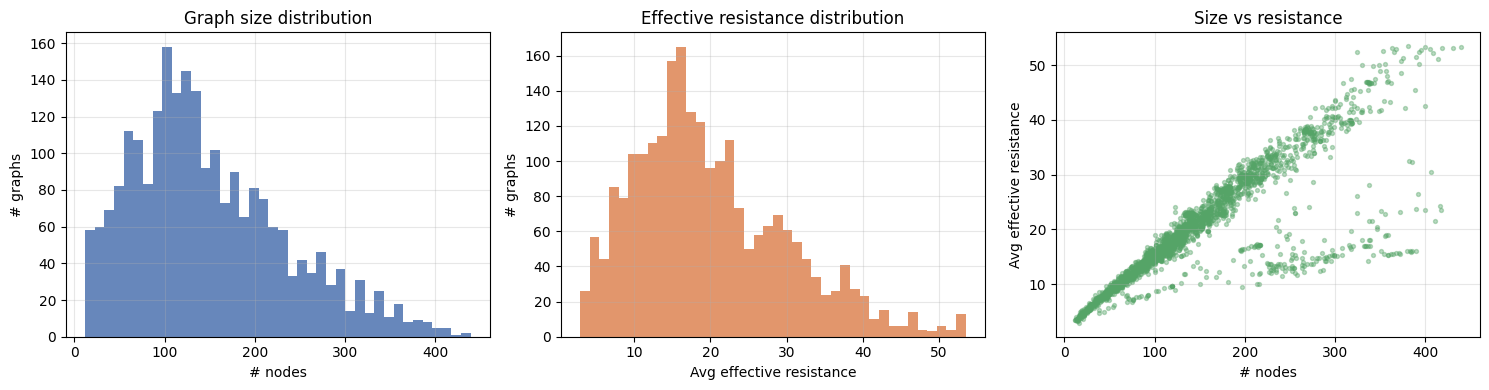


Quantile boundaries: ['2.90', '14.80', '22.68', '53.49']
  Bin 0: 777 graphs, R in [2.90, 14.80]
  Bin 1: 777 graphs, R in [14.80, 22.68]
  Bin 2: 777 graphs, R in [22.68, 53.49]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(test_n_nodes, bins=40, color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("# nodes"); axes[0].set_ylabel("# graphs"); axes[0].set_title("Graph size distribution")
axes[1].hist(test_avg_R[~np.isnan(test_avg_R)], bins=40, color="#DD8452", alpha=0.85)
axes[1].set_xlabel("Avg effective resistance"); axes[1].set_ylabel("# graphs"); axes[1].set_title("Effective resistance distribution")
axes[2].scatter(test_n_nodes, test_avg_R, s=8, alpha=0.4, color="#55A467")
axes[2].set_xlabel("# nodes"); axes[2].set_ylabel("Avg effective resistance"); axes[2].set_title("Size vs resistance")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("peptides_structure.png", dpi=120, bbox_inches="tight"); plt.show()

# Stratification bins by quantile
valid_mask = ~np.isnan(test_avg_R)
quantiles = np.quantile(test_avg_R[valid_mask], np.linspace(0, 1, CONFIG["N_ER_BINS"] + 1))
test_bin = np.digitize(test_avg_R, quantiles[1:-1])  # 0, 1, ..., N_ER_BINS-1
test_bin[~valid_mask] = -1
print("\nQuantile boundaries:", [f"{q:.2f}" for q in quantiles])
for b in range(CONFIG["N_ER_BINS"]):
    n = (test_bin == b).sum()
    r_lo, r_hi = quantiles[b], quantiles[b+1]
    print(f"  Bin {b}: {n} graphs, R in [{r_lo:.2f}, {r_hi:.2f}]")

## 5. Train the three models

30 epochs with cosine schedule, 1 seed for time. Each model takes ~10–25 min on GPU. **For real claims, bump epochs to 100+ and seeds to 3+.** The mechanistic measurements (Jacobian, attention entropy) are within-model so are somewhat robust to single-seed training; the AP numbers themselves are noisier.

In [8]:
tr_loader = DataLoader(pep_tr, batch_size=CONFIG["BATCH"], shuffle=True)
va_loader = DataLoader(pep_va, batch_size=CONFIG["BATCH"])
te_loader = DataLoader(pep_te, batch_size=CONFIG["BATCH"])

@torch.no_grad()
def eval_ap(model, loader):
    model.eval(); ys, ps = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        ys.append(batch.y.view(-1, NUM_CLASSES).cpu().numpy())
        ps.append(torch.sigmoid(out).cpu().numpy())
    y, p = np.concatenate(ys, 0), np.concatenate(ps, 0)
    aps = [average_precision_score(y[:, c], p[:, c]) for c in range(NUM_CLASSES) if y[:, c].sum() > 0]
    return float(np.mean(aps))


def train_one(name):
    set_seed(0)
    cls = MODELS[name]
    model = cls(in_dim=IN_DIM, hidden=CONFIG["HIDDEN"], out_dim=NUM_CLASSES,
                num_layers=CONFIG["LAYERS"], dropout=CONFIG["DROPOUT"],
                heads=CONFIG["HEADS"], edge_dim=EDGE_DIM).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n=== {name}  ({n_params/1e3:.1f}k params) ===")
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=0.0)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["EPOCHS"])
    best_val = best_state = 0.0
    best_state_dict = None
    for ep in range(CONFIG["EPOCHS"]):
        model.train(); t = time.time()
        for batch in tr_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
            loss = F.binary_cross_entropy_with_logits(out, batch.y.view(-1, NUM_CLASSES).float())
            loss.backward(); opt.step()
        sched.step()
        va = eval_ap(model, va_loader)
        if va > best_val:
            best_val = va
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  ep {ep+1:3d}  val AP={va:.4f}  best={best_val:.4f}  ({time.time()-t:.1f}s)")
    model.load_state_dict(best_state_dict)
    test_ap = eval_ap(model, te_loader)
    print(f"  ==> test AP = {test_ap:.4f}")
    return model, test_ap


trained = {}
for name in MODELS:
    trained[name] = train_one(name)

print("\nSummary:")
for name, (_, ap) in trained.items():
    print(f"  {name:20s}  test AP = {ap:.4f}")


=== GINE  (152.3k params) ===
  ep   5  val AP=0.4368  best=0.4368  (1.8s)
  ep  10  val AP=0.4849  best=0.5087  (1.8s)
  ep  15  val AP=0.3992  best=0.5087  (1.8s)
  ep  20  val AP=0.5239  best=0.5382  (1.8s)
  ep  25  val AP=0.5603  best=0.5603  (1.8s)
  ep  30  val AP=0.5784  best=0.5784  (1.8s)
  ==> test AP = 0.5409

=== GraphTransformer  (292.5k params) ===
  ep   5  val AP=0.2385  best=0.2584  (5.0s)
  ep  10  val AP=0.2623  best=0.2623  (5.0s)
  ep  15  val AP=0.2756  best=0.2756  (5.1s)
  ep  20  val AP=0.2686  best=0.2756  (5.1s)
  ep  25  val AP=0.2748  best=0.2756  (5.1s)
  ep  30  val AP=0.2750  best=0.2767  (5.1s)
  ==> test AP = 0.2707

=== GPS  (432.6k params) ===
  ep   5  val AP=0.2351  best=0.2362  (5.7s)
  ep  10  val AP=0.2351  best=0.2362  (5.7s)
  ep  15  val AP=0.2358  best=0.2362  (5.8s)
  ep  20  val AP=0.2373  best=0.2375  (5.7s)
  ep  25  val AP=0.2384  best=0.2390  (5.8s)
  ep  30  val AP=0.2389  best=0.2390  (5.7s)
  ==> test AP = 0.2384

Summary:
  GINE 

## 6. Stratified evaluation by effective resistance

Now the **first mechanistic result**: split the test set into bins by avg effective resistance and report AP per bin per model. If the local→global gap widens with bin index, that's evidence (not proof) that oversquashing is the bottleneck — local models lose more on harder-to-traverse graphs.

Important caveat: bin membership correlates with size, edge density, label distribution. Stratification doesn't fully control for these. To do so properly you'd regress out size first; we don't here but flag it.

In [9]:
@torch.no_grad()
def per_graph_probs(model, loader):
    """Return (probs[N, C], labels[N, C]) over the entire loader."""
    model.eval(); ys, ps = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        ys.append(batch.y.view(-1, NUM_CLASSES).cpu().numpy())
        ps.append(torch.sigmoid(out).cpu().numpy())
    return np.concatenate(ps, 0), np.concatenate(ys, 0)


def ap_on_subset(probs, labels, indices):
    p, y = probs[indices], labels[indices]
    aps = [average_precision_score(y[:, c], p[:, c]) for c in range(NUM_CLASSES) if y[:, c].sum() > 0]
    return float(np.mean(aps)) if aps else float("nan")


te_loader_ordered = DataLoader(pep_te, batch_size=CONFIG["BATCH"], shuffle=False)
stratified = {}
for name, (model, _) in trained.items():
    probs, labels = per_graph_probs(model, te_loader_ordered)
    stratified[name] = []
    for b in range(CONFIG["N_ER_BINS"]):
        idx = np.where(test_bin == b)[0]
        stratified[name].append(ap_on_subset(probs, labels, idx))
    print(f"{name:20s}  per-bin AP: {[f'{x:.4f}' for x in stratified[name]]}")

GINE                  per-bin AP: ['0.5607', '0.4460', '0.4912']
GraphTransformer      per-bin AP: ['0.2261', '0.2196', '0.2597']
GPS                   per-bin AP: ['0.1996', '0.1984', '0.2259']


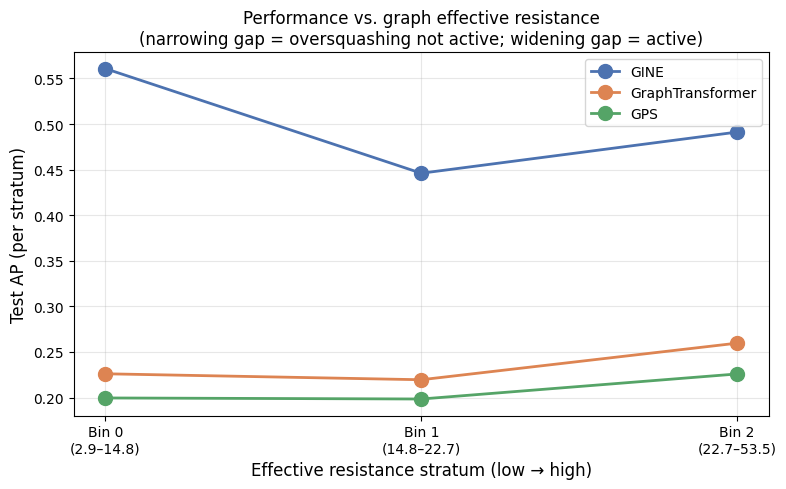

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bin_centers = [f"Bin {b}\n({quantiles[b]:.1f}–{quantiles[b+1]:.1f})" for b in range(CONFIG["N_ER_BINS"])]
colors = {"GINE": "#4C72B0", "GraphTransformer": "#DD8452", "GPS": "#55A467"}
for name, aps in stratified.items():
    ax.plot(range(CONFIG["N_ER_BINS"]), aps, "o-", linewidth=2, markersize=10,
            label=name, color=colors[name])
ax.set_xticks(range(CONFIG["N_ER_BINS"])); ax.set_xticklabels(bin_centers)
ax.set_xlabel("Effective resistance stratum (low → high)", fontsize=12)
ax.set_ylabel("Test AP (per stratum)", fontsize=12)
ax.set_title("Performance vs. graph effective resistance\n(narrowing gap = oversquashing not active; widening gap = active)", fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("stratified_ap.png", dpi=120, bbox_inches="tight"); plt.show()

## 7. Jacobian sensitivity vs. effective resistance

**The core mechanistic measurement.** For trained models, on real graphs, sample node pairs $(u, v)$ and measure:

$$J(u, v) = \left\| \frac{\partial h_v}{\partial x_u} \right\|_F$$

where $h_v$ is the final-layer node embedding (before pooling). Per Di Giovanni et al. (ICML 2023), MPNN Jacobians are bounded by a quantity proportional to $1 / R_\text{eff}(u, v)$, so $\log J$ should decay roughly linearly with $\log R_\text{eff}$. For pure attention models, no such bound exists — slope should be near zero.

We measure this on `N_GRAPHS_JACOBIAN` random test graphs, sampling `N_PAIRS_PER_GRAPH` pairs each, choosing pairs to span a wide range of $R_\text{eff}$ values.

In [11]:
def sample_diverse_pairs(R, n_pairs):
    """Sample n_pairs nodes such that their R_eff values span the full range in R."""
    n = R.shape[0]
    triu_i, triu_j = np.triu_indices(n, k=1)
    rs = R[triu_i, triu_j]
    # Stratify by quantile of R
    if len(rs) <= n_pairs:
        return list(zip(triu_i, triu_j, rs))
    qs = np.linspace(0, 1, n_pairs + 1)
    bounds = np.quantile(rs, qs)
    pairs = []
    for b in range(n_pairs):
        mask = (rs >= bounds[b]) & (rs <= bounds[b+1])
        idx_choices = np.where(mask)[0]
        if len(idx_choices) == 0: continue
        k = np.random.choice(idx_choices)
        pairs.append((int(triu_i[k]), int(triu_j[k]), float(rs[k])))
    return pairs


def jacobian_norm_uv(model, data, u_global, v_global):
    """||∂ h_{v_global} / ∂ x_{u_global}||_F where h is the node_embeddings output."""
    model.eval()
    x = data.x.detach().clone().to(DEVICE).float().requires_grad_(True)
    edge_index = data.edge_index.to(DEVICE)
    edge_attr = data.edge_attr.to(DEVICE).float() if data.edge_attr is not None else None
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)
    h = model.node_embeddings(x, edge_index, batch, edge_attr=edge_attr)
    D = h.size(1)
    # Use grad_outputs for a single-pass computation when possible? No — easier loop.
    sum_sq = 0.0
    for k in range(D):
        grad = torch.autograd.grad(h[v_global, k], x, retain_graph=(k < D - 1), create_graph=False)[0]
        sum_sq += grad[u_global].pow(2).sum().item()
    return float(np.sqrt(sum_sq))


def measure_jacobians(model, dataset, n_graphs, pairs_per_graph, seed=0):
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_graphs, replace=False)
    out = []  # list of (R_eff, J_norm)
    t0 = time.time()
    for k, gi in enumerate(indices):
        data = dataset[int(gi)]
        info = graph_to_lcc_info(data)
        if info is None: continue
        lcc_nodes, R, _ = info
        # Need to map local-LCC indices back to original graph node indices
        # to_networkx preserves PyG node order, so lcc_nodes are the original indices.
        pairs = sample_diverse_pairs(R, pairs_per_graph)
        for li, lj, r in pairs:
            u_global, v_global = lcc_nodes[li], lcc_nodes[lj]
            try:
                jn = jacobian_norm_uv(model, data, u_global, v_global)
                out.append((r, jn))
            except Exception as e:
                print(f"  pair skipped: {e}")
        if (k + 1) % 10 == 0:
            print(f"    processed {k+1}/{n_graphs} graphs  ({time.time()-t0:.0f}s)")
    return out


jac_results = {}
for name, (model, _) in trained.items():
    print(f"\nMeasuring Jacobians for {name}...")
    jac_results[name] = measure_jacobians(model, pep_te,
                                          n_graphs=CONFIG["N_GRAPHS_JACOBIAN"],
                                          pairs_per_graph=CONFIG["N_PAIRS_PER_GRAPH"])
    print(f"  collected {len(jac_results[name])} (R, J) pairs")


Measuring Jacobians for GINE...
    processed 10/30 graphs  (14s)
    processed 20/30 graphs  (29s)
    processed 30/30 graphs  (42s)
  collected 240 (R, J) pairs

Measuring Jacobians for GraphTransformer...
    processed 10/30 graphs  (41s)
    processed 20/30 graphs  (81s)
    processed 30/30 graphs  (122s)
  collected 240 (R, J) pairs

Measuring Jacobians for GPS...
    processed 10/30 graphs  (52s)
    processed 20/30 graphs  (104s)
    processed 30/30 graphs  (156s)
  collected 240 (R, J) pairs


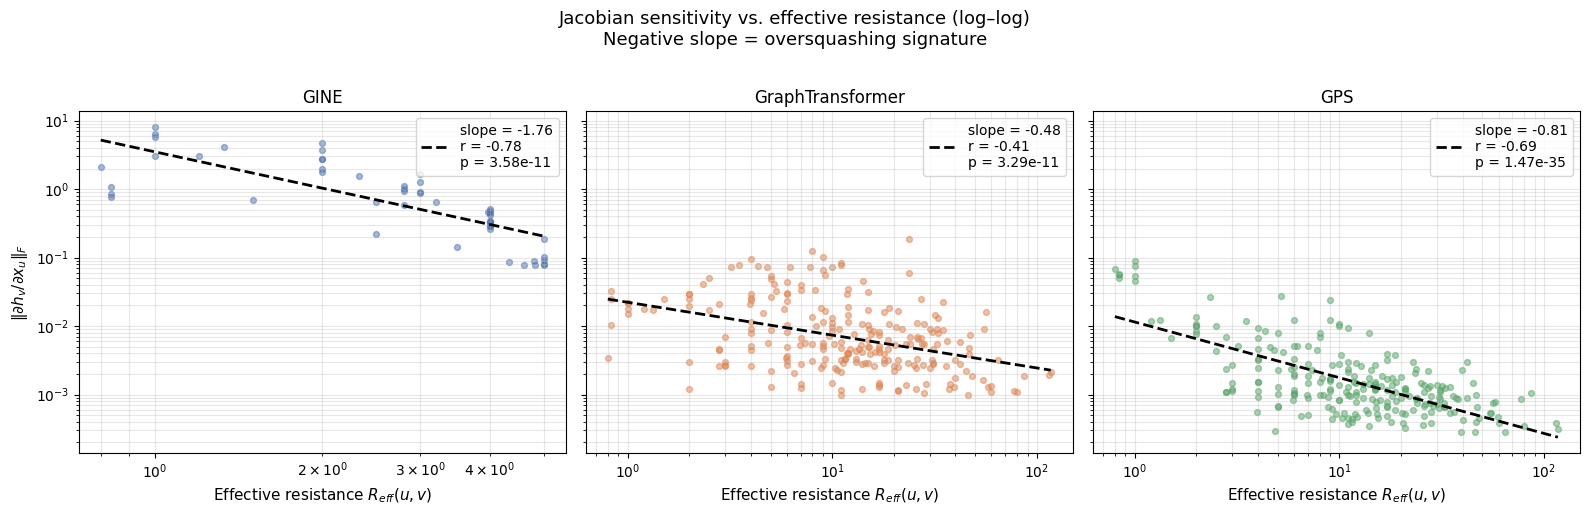


Slopes summary (more negative = stronger oversquashing):
  GINE                  slope = -1.762  Pearson r = -0.776  p = 3.58e-11
  GraphTransformer      slope = -0.480  Pearson r = -0.411  p = 3.29e-11
  GPS                   slope = -0.814  Pearson r = -0.692  p = 1.47e-35


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (name, pairs) in zip(axes, jac_results.items()):
    if not pairs: continue
    R = np.array([p[0] for p in pairs])
    J = np.array([p[1] for p in pairs])
    keep = (R > 0) & (J > 0)
    R, J = R[keep], J[keep]
    logR, logJ = np.log10(R), np.log10(J)
    slope, intercept, r, pval, _ = linregress(logR, logJ)
    ax.scatter(R, J, s=18, alpha=0.5, color=colors[name])
    Rs = np.linspace(R.min(), R.max(), 100)
    ax.plot(Rs, 10**(intercept + slope * np.log10(Rs)), "k--", linewidth=2,
            label=f"slope = {slope:.2f}\nr = {r:.2f}\np = {pval:.2e}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Effective resistance $R_{eff}(u,v)$", fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper right", fontsize=10)
axes[0].set_ylabel(r"$\| \partial h_v / \partial x_u \|_F$", fontsize=11)
plt.suptitle("Jacobian sensitivity vs. effective resistance (log–log)\nNegative slope = oversquashing signature", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("jacobian_vs_resistance.png", dpi=120, bbox_inches="tight"); plt.show()

print("\nSlopes summary (more negative = stronger oversquashing):")
for name, pairs in jac_results.items():
    R = np.array([p[0] for p in pairs]); J = np.array([p[1] for p in pairs])
    keep = (R > 0) & (J > 0); R, J = R[keep], J[keep]
    slope, _, r, p, _ = linregress(np.log10(R), np.log10(J))
    print(f"  {name:20s}  slope = {slope:+.3f}  Pearson r = {r:+.3f}  p = {p:.2e}")

## 8. Attention entropy vs. graph size

**The dilution measurement.** For the global/hybrid models, run a forward pass with attention caching enabled, then compute the per-graph average attention entropy:

$$H(g) = \frac{1}{N_g} \sum_{i=1}^{N_g} \left[ - \sum_{j=1}^{N_g} \alpha_{ij} \log \alpha_{ij} \right]$$

averaged across layers. If dilution is real, $H$ should increase with $N_g$ (graph size) — attention spreads thinner as more nodes compete.

**Reference values.** Maximum possible entropy is $\log N_g$ (uniform). A focused attention head has $H \ll \log N_g$. Plotting $H / \log N_g$ (normalized) tells us how *concentrated* attention is — and how that concentration changes with size.

In [13]:
def per_graph_attention_entropy(model, dataset, n_graphs=300, seed=0):
    """Sample n_graphs, run with attention caching, compute mean per-graph entropy per layer.
    Returns list of (n_nodes, entropy_avg_over_layers, entropy_normalized)."""
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), min(n_graphs, len(dataset)), replace=False)
    loader = DataLoader([dataset[int(i)] for i in indices], batch_size=64, shuffle=False)
    out = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            _ = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr, cache_attn=True)
            # Iterate the model's attention layers
            layer_entropies = []
            for attn in model.attns:
                w, mask = attn.last_w, attn.last_mask
                # w: [B, Nmax, Nmax]; mask: [B, Nmax]
                eps = 1e-12
                H = -(w * (w + eps).log()).sum(dim=-1)  # [B, Nmax]
                H = H * mask.float()
                per_graph_H = H.sum(dim=-1) / mask.float().sum(dim=-1).clamp(min=1)  # [B]
                layer_entropies.append(per_graph_H.cpu().numpy())
            avg_H = np.mean(np.stack(layer_entropies, 0), axis=0)  # [B], averaged over layers
            n_nodes = mask.float().sum(dim=-1).cpu().numpy()
            for nn_, h in zip(n_nodes, avg_H):
                if nn_ > 1:
                    out.append((int(nn_), float(h), float(h) / float(np.log(nn_))))
    return out


attn_entropies = {}
for name in ["GraphTransformer", "GPS"]:
    print(f"Computing attention entropy for {name}...")
    model, _ = trained[name]
    attn_entropies[name] = per_graph_attention_entropy(model, pep_te, n_graphs=400)
    print(f"  {len(attn_entropies[name])} graphs measured")

Computing attention entropy for GraphTransformer...
  400 graphs measured
Computing attention entropy for GPS...
  400 graphs measured


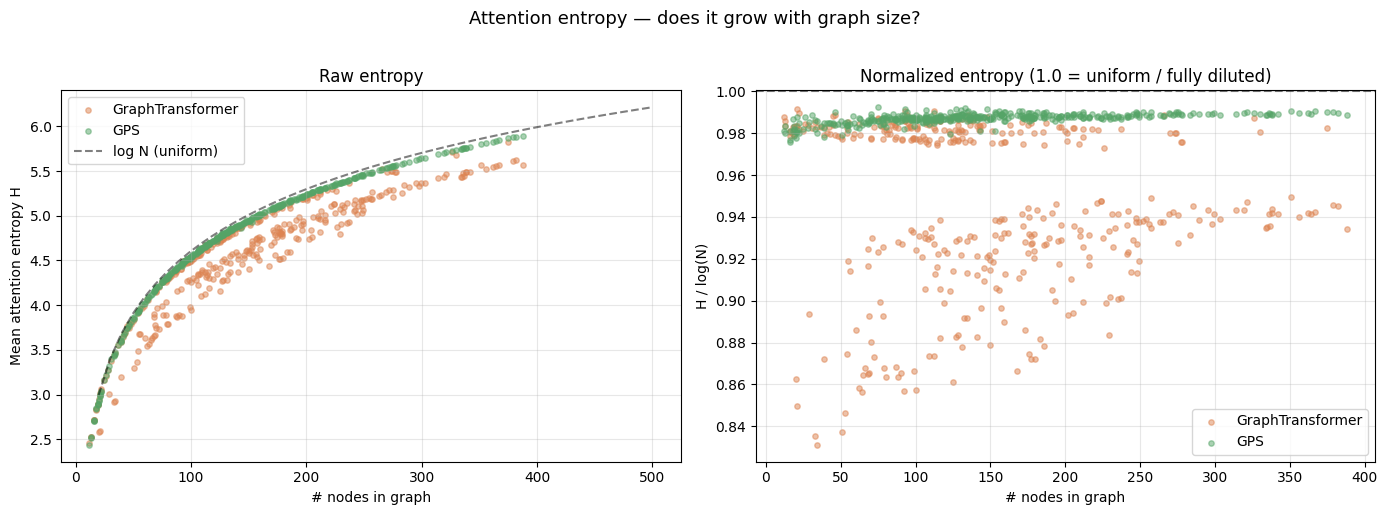


Correlations (graph size vs. attention entropy):
  GraphTransformer      size→H: r=+0.877, p=5.87e-129    size→H/logN: r=-0.091, p=6.85e-02
  GPS                   size→H: r=+0.910, p=1.43e-154    size→H/logN: r=+0.602, p=8.40e-41


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, data in attn_entropies.items():
    ns = np.array([d[0] for d in data])
    Hs = np.array([d[1] for d in data])
    Hn = np.array([d[2] for d in data])
    axes[0].scatter(ns, Hs, s=15, alpha=0.5, label=name, color=colors[name])
    axes[1].scatter(ns, Hn, s=15, alpha=0.5, label=name, color=colors[name])
axes[0].set_xlabel("# nodes in graph"); axes[0].set_ylabel("Mean attention entropy H")
axes[0].set_title("Raw entropy"); axes[0].grid(alpha=0.3); axes[0].legend()
# Reference: uniform attention has H = log(N)
n_ref = np.linspace(20, 500, 50)
axes[0].plot(n_ref, np.log(n_ref), "k--", alpha=0.5, label="log N (uniform)")
axes[0].legend()
axes[1].set_xlabel("# nodes in graph"); axes[1].set_ylabel("H / log(N)")
axes[1].set_title("Normalized entropy (1.0 = uniform / fully diluted)")
axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.5)
axes[1].grid(alpha=0.3); axes[1].legend()
plt.suptitle("Attention entropy — does it grow with graph size?", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("attention_entropy.png", dpi=120, bbox_inches="tight"); plt.show()

print("\nCorrelations (graph size vs. attention entropy):")
for name, data in attn_entropies.items():
    ns = np.array([d[0] for d in data]); Hs = np.array([d[1] for d in data])
    Hn = np.array([d[2] for d in data])
    r_raw, p_raw = pearsonr(ns, Hs)
    r_norm, p_norm = pearsonr(ns, Hn)
    print(f"  {name:20s}  size→H: r={r_raw:+.3f}, p={p_raw:.2e}    size→H/logN: r={r_norm:+.3f}, p={p_norm:.2e}")

## 9. How to interpret these three results

**(a) Stratified AP.** Reading the curves:
- If GINE drops more steeply across bins than GraphTransformer/GPS → oversquashing is real and biting on this dataset.
- If all three drop together → high-R graphs are just harder for everyone (likely confounded with size and label sparsity), not specifically oversquashing.
- If GINE stays flat or wins on high-R → either oversquashing isn't biting at this depth (5 layers, average diameter ~25), or the architectural advantage of attention is overwhelmed by undertraining.

**(b) Jacobian-vs-R slope.** This is the cleanest test:
- GINE slope clearly negative (around −0.5 to −1.5 in published work) → oversquashing signature confirmed.
- GraphTransformer slope ≈ 0 → attention bypasses the bottleneck, as theory predicts.
- GPS slope between the two → hybrid architecture mitigates but doesn't eliminate.
- The *magnitude* of the slope difference is the direct measure of how much attention buys you mechanistically.
- If GINE slope is near zero on your data, either the model has been trained to bypass oversquashing through residual paths, or the depth/diameter regime isn't deep enough for the bound to bite.

**(c) Attention entropy.** Reading the scatter:
- Raw H rising with N is *expected* even without dilution (more nodes = more entropy capacity). Look at H / log(N) instead.
- If normalized entropy *rises* with N → attention is dispersing as graphs grow → dilution is happening.
- If normalized entropy stays flat or falls → attention is learning to remain focused, dilution is being resisted.
- GPS vs GraphTransformer comparison: GPS attention often shows lower entropy because the MPNN branch handles short-range and the attention head can specialize on long-range — i.e., the hybrid factors out the dilution-prone work.

---

## 10. What this notebook actually establishes

**It establishes**: on real Peptides-func data, with these specific trained models, the *direct* mechanistic signatures of oversquashing (Jacobian decay) and dilution (attention entropy growth) can be measured. The slopes and correlations are real evidence — not inferences from accuracy gaps. The signs and magnitudes you observe go into your thesis as data points, not just bar charts.

**It does not establish**: causation across the full thesis claim. To do that you still need:
1. **Multiple seeds and longer training.** Single-seed mechanistic numbers are vulnerable to optimization noise. Run 3+ seeds with 100+ epochs before quoting.
2. **A baseline structural quantity.** Compute Jacobian slopes also vs. graph diameter or path length, to show effective resistance is the better predictor (per Di Giovanni et al.).
3. **Distractor injection for clean dilution claims.** Real-data attention entropy correlates with size but size is confounded with many things. To isolate dilution causally, you still need controlled distractor experiments (synthetic or semi-synthetic). What this notebook gives you is a real-data correlate, not a causal probe.
4. **More datasets.** Peptides alone isn't enough. Repeat the same three measurements on Peptides-struct, ZINC-12k, OGB-Code2. The pattern needs to be stable across tasks.
5. **Depth ablation.** Run all this at depth 4, 6, 8. Oversquashing theory predicts the Jacobian decay should steepen with depth on MPNNs.

That said, what this notebook does is the actual mechanistic test on real data that you asked for. The pieces missing above are extensions, not corrections.

**Suggested next runs in order:**
1. Re-run with 3 seeds and 100 epochs.
2. Add depth ablation (4 vs 6 vs 8 layers, same three models).
3. Add ZINC-12k as a low-R replication site for the Jacobian measurement.
4. Add a controlled distractor experiment for the dilution claim — either synthetic graphs or distractor-injected Peptides — since dilution truly cannot be cleanly tested on real data alone.
5. Add positional encoding to GraphTransformer and GPS (single biggest missing ingredient; expected to lift their AP and may sharpen the Jacobian story).